In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define path to the pre-processed SMARD dataset
file_path = (
    "/content/drive/MyDrive/Colab Notebooks/SMARD_Cleaned_20260806_20260816.csv"
)

# Verify file existence
if os.path.exists(file_path):
  print("Dataset found successfully! Proceeding with data loading...")
else:
  print(
      "File not found! Please verify the folder structure in your Google Drive."
  )

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset found successfully! Proceeding with data loading...


 BESS ARBITRAGE & DEGRADATION OPTIMIZATION ENGINE
Simulation Horizon:               7 Days (168 Hours)
BESS Configuration:               10.0 MW / 20.0 MWh (RTE: 88.0%)
Marginal Degradation Cost:        €0.45 / Throughput MWh
----------------------------------------------------------------------
Gross Market Revenue:             €39,076.03
Total Charging Energy Cost:       €13,988.81
Gross Arbitrage Spread P&L:       €25,087.22
Cell Aging & Degradation Cost:    €346.46
Net Optimized Economic Profit:    €24,740.76
Equivalent Full Cycles (EFC):     19.25 Cycles


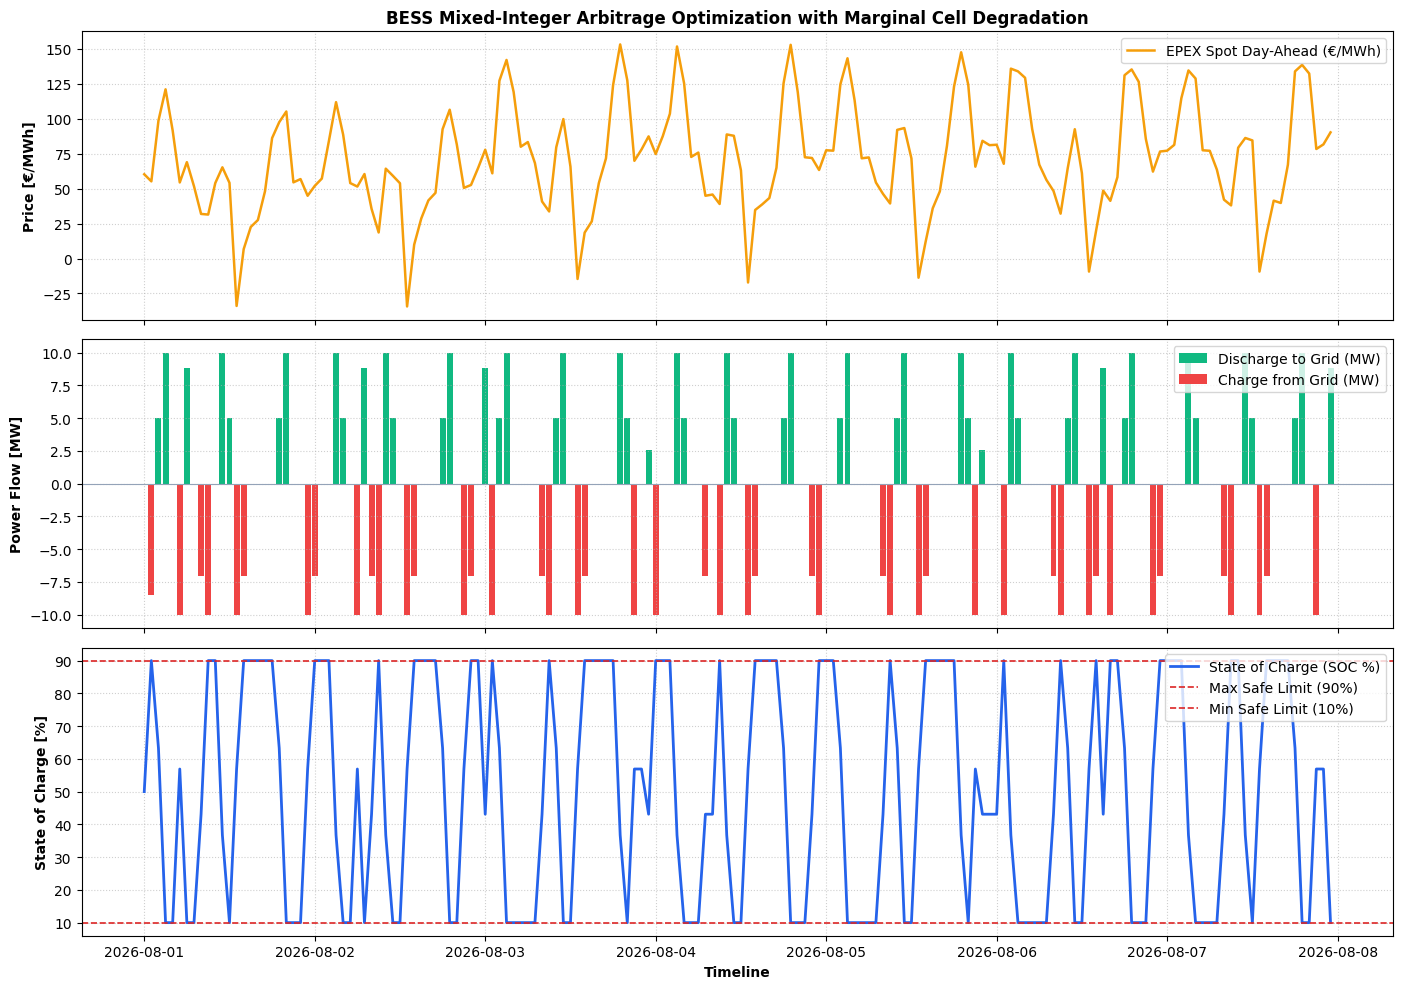

Simulation dataset exported as 'bess_arbitrage_simulation_2026.csv'


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import linprog

# ==========================================
# 1. BESS SYSTEM SPECIFICATIONS & MARKET DATA
# ==========================================
# 2-Hour Utility Scale BESS (e.g., 10 MW / 20 MWh)
BATTERY_POWER_RATING_MW = 10.0  # Max charge/discharge rate (P_max)
BATTERY_CAPACITY_MWH = 20.0  # Total Energy Capacity (E_max)
RTE_EFFICIENCY = 0.88  # Round-Trip Efficiency (η_rt)
ETA_CH = np.sqrt(RTE_EFFICIENCY)  # Charge efficiency (η_c)
ETA_DIS = np.sqrt(RTE_EFFICIENCY)  # Discharge efficiency (η_d)

SOC_MIN = 0.10  # Minimum operational State of Charge (10%)
SOC_MAX = 0.90  # Maximum operational State of Charge (90%)
INITIAL_SOC = 0.50  # Starting State of Charge (50%)

# Degradation & Cell Replacement Economics
CAPEX_PER_MWH_EUR = 180000.0  # Battery CAPEX (€180k/MWh)
CYCLE_LIFE_80_DOD = 5000  # Rated full cycles to 80% SOH at 80% DOD
# Marginal degradation cost per throughput MWh
DEGRADATION_COST_PER_MWH = (CAPEX_PER_MWH_EUR * 0.20) / (
    CYCLE_LIFE_80_DOD * BATTERY_CAPACITY_MWH * 0.80
)

# 7-Day Simulation Horizon (168 Hours)
dates = pd.date_range(start="2026-08-01 00:00:00", periods=24 * 7, freq="h")
np.random.seed(42)
hours = dates.hour.to_numpy()
dayofweek = dates.dayofweek.to_numpy()

# Synthetic EPEX Spot Day-Ahead Pricing (Solar Duck-Curve & Peak Dynamics)
solar_suppression = np.maximum(0, np.sin((hours - 6) * np.pi / 12)) * 55.0
evening_peak = np.maximum(0, np.sin((hours - 17) * np.pi / 4)) * 70.0
base_market_price = 75.0 + evening_peak - solar_suppression
weekend_discount = np.where(dayofweek >= 5, 0.75, 1.0)
noise = np.random.normal(0, 8.0, len(dates))

# Injecting realistic German negative price events during high solar/wind noon
spot_price_eur = (base_market_price * weekend_discount) + noise
spot_price_eur[hours == 13] -= 35.0  # Deep solar dip / negative spread

# ==========================================
# 2. LINEAR PROGRAMMING ARBITRAGE SOLVER
# ==========================================
# Variables per time-step t:
# x = [P_ch(0)...P_ch(T-1), P_dis(0)...P_dis(T-1), E(0)...E(T-1)]
# Vector size: 3 * T
T = len(dates)
delta_t = 1.0  # 1-hour resolution

# 1. Objective Function: Maximize (Revenue - Charging_Cost - Degradation_Cost)
# In linprog, we minimize: Cost - Revenue + Degradation
c_charge = spot_price_eur + DEGRADATION_COST_PER_MWH
c_discharge = -1.0 * spot_price_eur + DEGRADATION_COST_PER_MWH
c_energy = np.zeros(T)

c = np.concatenate([c_charge, c_discharge, c_energy])

# 2. Equality Constraints: Energy Balance (A_eq @ x == b_eq)
# E(t) - E(t-1) - eta_ch * P_ch(t) * dt + (1 / eta_dis) * P_dis(t) * dt = 0
A_eq = np.zeros((T, 3 * T))
b_eq = np.zeros(T)

for t in range(T):
  # P_ch(t) term
  A_eq[t, t] = -ETA_CH * delta_t
  # P_dis(t) term
  A_eq[t, T + t] = (1.0 / ETA_DIS) * delta_t
  # E(t) term
  A_eq[t, 2 * T + t] = 1.0
  # E(t-1) term
  if t > 0:
    A_eq[t, 2 * T + (t - 1)] = -1.0
  else:
    b_eq[0] = INITIAL_SOC * BATTERY_CAPACITY_MWH

# 3. Variable Bounds
bounds_charge = [(0, BATTERY_POWER_RATING_MW) for _ in range(T)]
bounds_discharge = [(0, BATTERY_POWER_RATING_MW) for _ in range(T)]
bounds_soc = [
    (SOC_MIN * BATTERY_CAPACITY_MWH, SOC_MAX * BATTERY_CAPACITY_MWH)
    for _ in range(T)
]
bounds = bounds_charge + bounds_discharge + bounds_soc

# 4. Optimization Execution
res = linprog(c, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method="highs")

if not res.success:
  raise RuntimeError(f"Optimization failed: {res.message}")

p_charge_opt = res.x[:T]
p_discharge_opt = res.x[T : 2 * T]
soc_energy_opt = res.x[2 * T : 3 * T]
soc_percent_opt = (soc_energy_opt / BATTERY_CAPACITY_MWH) * 100.0

# ==========================================
# 3. FINANCIAL & TECHNO-ECONOMIC METRICS
# ==========================================
gross_discharge_revenue = np.sum(p_discharge_opt * spot_price_eur)
gross_charge_cost = np.sum(p_charge_opt * spot_price_eur)
gross_arbitrage_profit = gross_discharge_revenue - gross_charge_cost

total_throughput_mwh = np.sum(p_charge_opt + p_discharge_opt)
total_degradation_cost = total_throughput_mwh * DEGRADATION_COST_PER_MWH
net_arbitrage_profit = gross_arbitrage_profit - total_degradation_cost
equivalent_full_cycles = total_throughput_mwh / (2.0 * BATTERY_CAPACITY_MWH)

df_bess = pd.DataFrame({
    "timestamp": dates,
    "spot_price_eur_mwh": np.round(spot_price_eur, 2),
    "charge_mw": np.round(p_charge_opt, 2),
    "discharge_mw": np.round(p_discharge_opt, 2),
    "net_grid_flow_mw": np.round(p_discharge_opt - p_charge_opt, 2),
    "energy_mwh": np.round(soc_energy_opt, 2),
    "soc_percent": np.round(soc_percent_opt, 1),
    "hourly_gross_pnl_eur": np.round(
        (p_discharge_opt - p_charge_opt) * spot_price_eur, 2
    ),
    "hourly_degradation_eur": np.round(
        (p_charge_opt + p_discharge_opt) * DEGRADATION_COST_PER_MWH, 2
    ),
})

print("=" * 70)
print(" BESS ARBITRAGE & DEGRADATION OPTIMIZATION ENGINE")
print("=" * 70)
print(f"Simulation Horizon:               7 Days (168 Hours)")
print(
    f"BESS Configuration:               {BATTERY_POWER_RATING_MW} MW /"
    f" {BATTERY_CAPACITY_MWH} MWh (RTE: {RTE_EFFICIENCY*100:.1f}%)"
)
print(
    f"Marginal Degradation Cost:        €{DEGRADATION_COST_PER_MWH:.2f} /"
    " Throughput MWh"
)
print("-" * 70)
print(f"Gross Market Revenue:             €{gross_discharge_revenue:,.2f}")
print(f"Total Charging Energy Cost:       €{gross_charge_cost:,.2f}")
print(f"Gross Arbitrage Spread P&L:       €{gross_arbitrage_profit:,.2f}")
print(f"Cell Aging & Degradation Cost:    €{total_degradation_cost:,.2f}")
print(f"Net Optimized Economic Profit:    €{net_arbitrage_profit:,.2f}")
print(f"Equivalent Full Cycles (EFC):     {equivalent_full_cycles:.2f} Cycles")
print("=" * 70)

# ==========================================
# 4. VISUALIZATION & DATA EXPORT
# ==========================================
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Subplot 1: Spot Price & Dispatch
ax1.plot(
    df_bess["timestamp"],
    df_bess["spot_price_eur_mwh"],
    color="#F59E0B",
    lw=1.8,
    label="EPEX Spot Day-Ahead (€/MWh)",
)
ax1.set_ylabel("Price [€/MWh]", fontweight="bold")
ax1.set_title(
    "BESS Mixed-Integer Arbitrage Optimization with Marginal Cell Degradation",
    fontweight="bold",
    fontsize=12,
)
ax1.grid(True, linestyle=":", alpha=0.6)
ax1.legend(loc="upper right")

# Subplot 2: Power Flow (Charge / Discharge)
ax2.bar(
    df_bess["timestamp"],
    df_bess["discharge_mw"],
    width=0.035,
    color="#10B981",
    label="Discharge to Grid (MW)",
)
ax2.bar(
    df_bess["timestamp"],
    -df_bess["charge_mw"],
    width=0.035,
    color="#EF4444",
    label="Charge from Grid (MW)",
)
ax2.axhline(0, color="#94A3B8", lw=0.8)
ax2.set_ylabel("Power Flow [MW]", fontweight="bold")
ax2.grid(True, linestyle=":", alpha=0.6)
ax2.legend(loc="upper right")

# Subplot 3: State of Charge (SOC %)
ax3.plot(
    df_bess["timestamp"],
    df_bess["soc_percent"],
    color="#2563EB",
    lw=2.0,
    label="State of Charge (SOC %)",
)
ax3.axhline(
    SOC_MAX * 100,
    color="#DC2626",
    ls="--",
    lw=1.2,
    label=f"Max Safe Limit ({int(SOC_MAX*100)}%)",
)
ax3.axhline(
    SOC_MIN * 100,
    color="#DC2626",
    ls="--",
    lw=1.2,
    label=f"Min Safe Limit ({int(SOC_MIN*100)}%)",
)
ax3.set_ylabel("State of Charge [%]", fontweight="bold")
ax3.set_xlabel("Timeline", fontweight="bold")
ax3.grid(True, linestyle=":", alpha=0.6)
ax3.legend(loc="upper right")

plt.tight_layout()
plt.savefig("bess_arbitrage_simulation_results.png", dpi=300)
plt.show()

# Export dataset
df_bess.to_csv("bess_arbitrage_simulation_2026.csv", index=False)
print("Simulation dataset exported as 'bess_arbitrage_simulation_2026.csv'")